# Recreating ALE VIM Experiments

- Example 4. Theoretical Linear Model with Correlation
- Example 5. 

In [1]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline

from algorithms.ale import ale_1d, bin_selection
from algorithms.ale_vim import ale_global_main, ale_connected_total, ale_quantile_total
from utils import replicate_ale_vims

## Example 4

In [ ]:
def example_4_dgp(n, rho):
    mean = [0, 0, 0]
    # notice X3 is independent of X1 and X2
    cov = [[1, rho, 0], [rho, 1, 0], [0, 0, 1]]
    X = np.random.multivariate_normal(mean, cov, n)
    return X

def example_4_f(X, betas):
    return betas[0] * X[:, 0] + betas[1] * X[:, 1] + betas[2] * X[:, 2]

n = 100
dgp = lambda n: example_4_dgp(n, rho=0.5)
f = lambda X: example_4_f(X, betas=[3, 2, 1])
bins = bin_selection(n)

replicate_ale_vims(dgp, f, n=100, bins=bins, replications=10, categorical=False)


Replication 1: VIM 1 Main: 9.755245631886854, VIM 2 Main: 4.206525256397742, VIM 1 Connected: 9.109251513739562, VIM 2 Connected: 3.997969982854562, VIM 1 Quantile: 20.267116983208588, VIM 2 Quantile: 5.519249137076559
Replication 2: VIM 1 Main: 9.629427060660955, VIM 2 Main: 4.2988688998013265, VIM 1 Connected: 9.700947119023162, VIM 2 Connected: 4.968226380080478, VIM 1 Quantile: 26.554734404330528, VIM 2 Quantile: 13.791337118539424
Replication 3: VIM 1 Main: 11.967416132048596, VIM 2 Main: 4.114309161334232, VIM 1 Connected: 11.201231981360007, VIM 2 Connected: 3.2223501012945475, VIM 1 Quantile: 11.256900752028914, VIM 2 Quantile: 6.95118590471913
Replication 4: VIM 1 Main: 11.70483439911237, VIM 2 Main: 4.815115467162636, VIM 1 Connected: 10.595407547416627, VIM 2 Connected: 5.193622602647699, VIM 1 Quantile: 23.47784942042685, VIM 2 Quantile: 9.66194992881989
Replication 5: VIM 1 Main: 10.578380888829265, VIM 2 Main: 3.9547622432778082, VIM 1 Connected: 9.008408334088717, VIM 2 

([np.float64(9.755245631886854),
  np.float64(9.629427060660955),
  np.float64(11.967416132048596),
  np.float64(11.70483439911237),
  np.float64(10.578380888829265),
  np.float64(9.089418165704192),
  np.float64(7.698700524584794),
  np.float64(15.188065593312606),
  np.float64(10.840977824485472),
  np.float64(8.104973526341226)],
 [np.float64(4.206525256397742),
  np.float64(4.2988688998013265),
  np.float64(4.114309161334232),
  np.float64(4.815115467162636),
  np.float64(3.9547622432778082),
  np.float64(3.8700836495256326),
  np.float64(4.823161163345169),
  np.float64(6.082298389340299),
  np.float64(4.7354253689489365),
  np.float64(4.3175788226655625)],
 [np.float64(9.109251513739562),
  np.float64(9.700947119023162),
  np.float64(11.201231981360007),
  np.float64(10.595407547416627),
  np.float64(9.008408334088717),
  np.float64(9.073124599394367),
  np.float64(8.546553283805874),
  np.float64(10.535432873619323),
  np.float64(10.766466407766364),
  np.float64(10.460831566329

## Example 5

In [24]:
# clean data
df = pd.read_csv("data/uci_bikesharing.csv")
df = df.dropna()
df["quarter"] = 1 + 4 * df["yr"] + df["mnth"] // 4
# rename mnth to month, hr to hour
df = df.rename(columns={"mnth": "month", "hr": "hour", "weathersit": "weather_situation"})
# keep only relevant columns
X = df[["quarter", "month", "hour", "holiday", "weekday", "workingday", "weather_situation", "atemp", "hum", "windspeed"]]
y = df["cnt"]

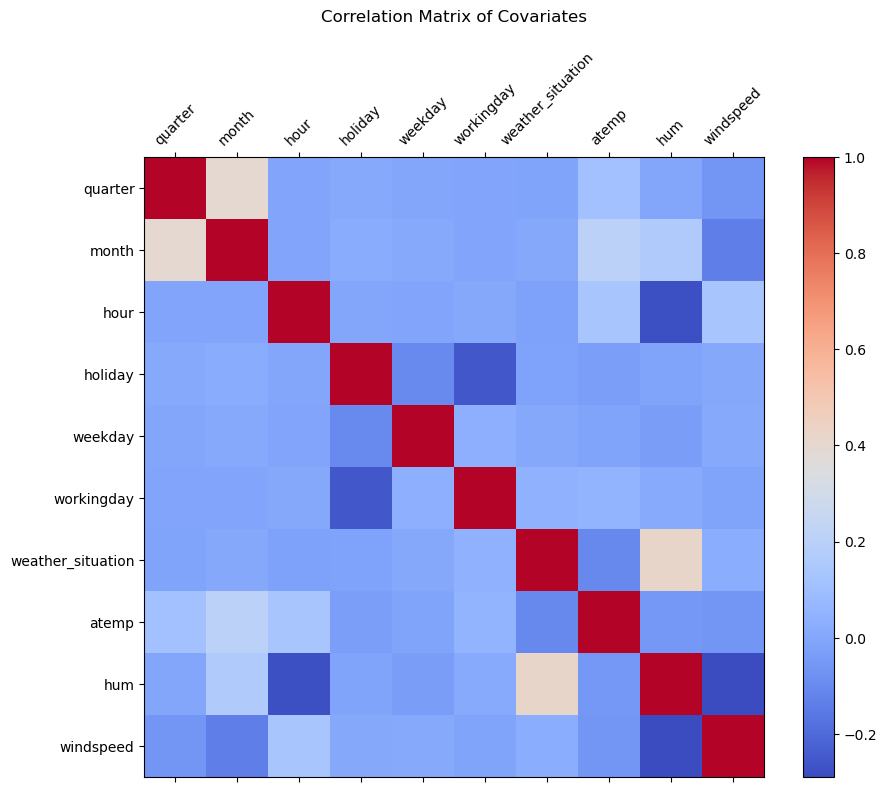

In [25]:
# correlation matrix of covariates
corr = X.corr()
plt.figure(figsize=(10, 8))
plt.matshow(corr, cmap='coolwarm', fignum=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Correlation Matrix of Covariates', pad=20)
plt.show()

In [26]:
def train_regressor(X_train, y_train):
    # train neural network with 1 hidden layer (35 nodes), relu activation, and 0.05 L2 regularization
    # NOTE: 35 nodes and 0.05 alpha were chosen based on previous cross-validation results in Apley and Zhu
    # perform log-transform on target variable to handle skewness
    model = TransformedTargetRegressor(
        regressor=MLPRegressor(hidden_layer_sizes=(35,), activation='relu', alpha=0.05, max_iter=1000, random_state=42),
        func=np.log,
        inverse_func=np.exp
    )
    
    model.fit(X_train, y_train)
    return model

In [27]:
def summarize_model_performance(model, X_test, y_test):
    # evaluate model performance
    y_pred = model.predict(X_test)
    y_pred = np.exp(y_pred)  # convert back to original scale
    y_true = np.exp(y_test)  # convert back to original scale
    mse = mean_squared_error(y_true, y_pred)
    print("Mean Squared Error:", mse)
    print("R^2:", model.score(X_test, y_test))

In [28]:
est = make_pipeline(
    TransformedTargetRegressor(
        regressor=MLPRegressor(hidden_layer_sizes=(5,), activation='relu', alpha=0.05, max_iter=1000, random_state=42),
        func=np.log,
        inverse_func=np.exp
    )
)
# TODO: find out why R^2 is so low (0.80, expect 0.93)

# cv = KFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(est, X, y, cv=cv, scoring='r2')
# print("Cross-validated R^2 scores:", scores)



In [29]:
covariate_names = X.columns.tolist()
X_list = X[:1600].to_numpy() # make round number for binning
y_list = y[:1600].to_numpy()
n = X_list.shape[0]
K = bin_selection(n)
est.fit(X_list, y_list)
# function to plug-in representing model
f = lambda x: est.predict(x)

In [30]:
covariate_names

['quarter',
 'month',
 'hour',
 'holiday',
 'weekday',
 'workingday',
 'weather_situation',
 'atemp',
 'hum',
 'windspeed']

In [31]:
categorical_features = ["quarter", "month", "hour", "holiday", "weekday", "workingday", "weather_situation"]

In [32]:
for i, predictor in enumerate(covariate_names):
    print(f"Feature: {predictor}")
    if predictor in categorical_features:
        continue
    categorical = predictor in categorical_features
    main = ale_global_main(f, X_list, i + 1, K, categorical=categorical)
    connected = ale_connected_total(f, X_list, i + 1, K, categorical=categorical)
    quantile = ale_quantile_total(f, X_list, i + 1, K, categorical=categorical)
    print(f"Main: {main}, Connected Total: {connected}, Quantile Total: {quantile}\n")

Feature: quarter
Feature: month
Feature: hour
Feature: holiday
Feature: weekday
Feature: workingday
Feature: weather_situation
Feature: atemp
[0.2879 0.2727 0.2727 ... 0.2273 0.2273 0.2273]
[False False False ... False False False]


/Users/dawsonren/Desktop/Experiments/ExplainableML/algorithms/ale.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  average_deltas[k - 1] = (1 / N_k[k - 1]) * np.sum(deltas[k_x == k])
/Users/dawsonren/Desktop/Experiments/ExplainableML/algorithms/ale.py:121: RuntimeWarning: invalid value encountered in scalar multiply
  average_deltas[k - 1] = (1 / N_k[k - 1]) * np.sum(deltas[k_x == k])


ValueError: could not broadcast input array from shape (23,10) into shape (40,10)